# Matching Pannstars

In [59]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1
and compute the median angular offset between matched sources.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame
import os
from glob import glob

### ----------- SExtractor Functions ----------- ###

def _get_column_names(read_line_object: List[str]) -> List[str]:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line.startswith('#')]
    return header

def _get_rows(read_line_object: List[str]) -> List[List[float]]:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if not line.startswith('#')]
    return data

def split_names_and_data(read_line_object: List[str]) -> Tuple[List[str], List[List[float]]]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = pd.DataFrame(data, columns=column_names)
    return data_frame

### ----------- Helper: Find RA/Dec columns ----------- ###

def _get_coord_columns(df: pd.DataFrame) -> Tuple[str, str]:
    """Find available RA/Dec column names in the SExtractor catalog."""
    if 'ALPHAPEAK_J2000' in df.columns and 'DELTAPEAK_J2000' in df.columns:
        return 'ALPHAPEAK_J2000', 'DELTAPEAK_J2000'
    elif 'ALPHA_J2000' in df.columns and 'DELTA_J2000' in df.columns:
        return 'ALPHA_J2000', 'DELTA_J2000'
    else:
        raise KeyError("No valid RA/Dec columns found in SExtractor catalog.")

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.ndarray, dec_new: np.ndarray, ra_catalog: np.ndarray, dec_catalog: np.ndarray):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- Catalog Matching Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str, band: str = 'i'):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)
        self.band = band.lower()
        # Detect RA/Dec columns automatically
        self.ra_col_dec, self.dec_col_dec = _get_coord_columns(self.sextractor_catalog)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""
        ra_decam = np.array(self.sextractor_catalog[self.ra_col_dec])
        dec_decam = np.array(self.sextractor_catalog[self.dec_col_dec])

        # Use band-specific RA/Dec from Pan-STARRS
        ra_col = f"{self.band}ra"
        dec_col = f"{self.band}dec"

        # Filter Pan-STARRS to remove bad entries
        pan = self.panstarrs_catalog
        valid = (pan[ra_col] > -999) & (pan[dec_col] > -90) & (pan[dec_col] < 90)
        pan = pan[valid].reset_index(drop=True)

        ra_panstars = np.array(pan[ra_col])
        dec_panstars = np.array(pan[dec_col])

        if len(ra_panstars) == 0 or len(dec_panstars) == 0:
            raise ValueError("Filtered Pan-STARRS catalog has no valid coordinates.")

        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)
        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = pan.iloc[idx_panstars].reset_index(drop=True)
        return matched_decam, matched_panstars

    def compute_centroid_offset(self, matched_decam: DataFrame, matched_panstars: DataFrame):
        """Compute and return median RA/Dec offset in arcseconds."""
        ra_decam = matched_decam[self.ra_col_dec].values
        dec_decam = matched_decam[self.dec_col_dec].values
        ra_panstars = matched_panstars[f'{self.band}ra'].values
        dec_panstars = matched_panstars[f'{self.band}dec'].values

        ra_offset_arcsec = (ra_decam - ra_panstars) * 3600.0
        dec_offset_arcsec = (dec_decam - dec_panstars) * 3600.0

        median_ra_offset = np.median(ra_offset_arcsec)
        median_dec_offset = np.median(dec_offset_arcsec)

        print(f"Median RA Offset: {median_ra_offset:.3f} arcsec")
        print(f"Median Dec Offset: {median_dec_offset:.3f} arcsec")
        return median_ra_offset, median_dec_offset

    def apply_offset_correction(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                                 ra_offset: float, dec_offset: float):
        """Apply offset correction and return updated DataFrames with corrected RA/Dec."""
        matched_decam = matched_decam.copy()
        matched_panstars = matched_panstars.copy()

        matched_decam['RA_CORRECTED'] = matched_decam[self.ra_col_dec] - (ra_offset / 3600.0)
        matched_decam['DEC_CORRECTED'] = matched_decam[self.dec_col_dec] - (dec_offset / 3600.0)

        matched_panstars['RA_CORRECTED'] = matched_panstars[f'{self.band}ra'] + (ra_offset / 3600.0)
        matched_panstars['DEC_CORRECTED'] = matched_panstars[f'{self.band}dec'] + (dec_offset / 3600.0)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                     decam_out: str, pan_out: str):
        """Save matched catalogs with corrected coordinates to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Main Execution ----------- ###

if __name__ == '__main__':
    # Define directory and Pan-STARRS path
    CAT_DIR = '/Users/aishwarya/Desktop/new_cdfs/cat'
    CAT_DIR1 = '/Users/aishwarya/Desktop/new_cdfs/cat_matched'
    PANSTARRS_PATH = '/Users/aishwarya/Desktop/new_cdfs/PS1_CDFS_Test1_aishusps.csv'

    # List all .cat files in the directory
    cat_files = glob(os.path.join(CAT_DIR, '*_depth.cat'))

    for cat_file in cat_files:
        base_filename = os.path.splitext(os.path.basename(cat_file))[0]
        print(f"\n--- Processing file: {base_filename} ---")

        try:
            # Create matcher and run cross-match pipeline
            matcher = CatalogMatcher(cat_file, PANSTARRS_PATH, band='i')  # Change to 'z' if needed
            matched_decam, matched_panstars = matcher.match_catalogs()

            if matched_decam.empty or matched_panstars.empty:
                print(f"No matches found for {base_filename}.")
                continue

            # Offset correction
            ra_offset, dec_offset = matcher.compute_centroid_offset(matched_decam, matched_panstars)
            matched_decam_corr, matched_panstars_corr = matcher.apply_offset_correction(
                matched_decam, matched_panstars, ra_offset, dec_offset
            )

            # Save with original file-based names
            decam_out = os.path.join(CAT_DIR1, f'{base_filename}_decam_matched.cat')
            panstarrs_out = os.path.join(CAT_DIR1, f'{base_filename}_panstarrs_matched.csv')
            matcher.save_matches(matched_decam_corr, matched_panstars_corr,
                                 decam_out=decam_out, pan_out=panstarrs_out)
        except Exception as e:
            print(f"Error processing {base_filename}: {e}")



--- Processing file: LBG_I_CDFS_depth ---
Median RA Offset: 0.044 arcsec
Median Dec Offset: 0.009 arcsec
Saved matched DECam to: /Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_panstarrs_matched.csv

--- Processing file: LBG_Y_CDFS_depth ---
Median RA Offset: 0.015 arcsec
Median Dec Offset: 0.022 arcsec
Saved matched DECam to: /Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Y_CDFS_depth_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Y_CDFS_depth_panstarrs_matched.csv

--- Processing file: LBG_Z_CDFS_depth ---
Median RA Offset: 0.048 arcsec
Median Dec Offset: 0.009 arcsec
Saved matched DECam to: /Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Z_CDFS_depth_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Z_CDFS_depth_panstarrs_matched.csv


# Y band matching

In [21]:
"""
Y-band cross-matching between SExtractor (DECam) and Pan-STARRS
(FULLY DEBUGGED VERSION)
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
import os
from glob import glob

# ============================================================
# SExtractor reader
# ============================================================
def _get_column_names(lines):
    return [line.split()[2] for line in lines if line.startswith('#')]

def _get_rows(lines):
    return [list(map(float, line.split())) for line in lines if not line.startswith('#')]

def read_cat(path):
    with open(path, encoding='utf8') as f:
        lines = f.readlines()
    cols = _get_column_names(lines)
    data = _get_rows(lines)
    return pd.DataFrame(data, columns=cols)

# ============================================================
# Get RA/Dec columns (DECam)
# ============================================================
def get_coord_columns(df):
    if 'ALPHAPEAK_J2000' in df.columns:
        return 'ALPHAPEAK_J2000', 'DELTAPEAK_J2000'
    elif 'ALPHA_J2000' in df.columns:
        return 'ALPHA_J2000', 'DELTA_J2000'
    else:
        raise KeyError("No RA/Dec columns found")

# ============================================================
# Cross-match
# ============================================================
def cross_match(ra1, dec1, ra2, dec2):

    c1 = SkyCoord(ra=ra1*u.deg, dec=dec1*u.deg)
    c2 = SkyCoord(ra=ra2*u.deg, dec=dec2*u.deg)

    idx, d2d, _ = c1.match_to_catalog_sky(c2)

    max_sep = 0.5 * u.arcsec
    good = d2d < max_sep

    return np.where(good)[0], idx[good], d2d[good]

# ============================================================
# Y-band matcher
# ============================================================
class YBandMatcher:

    def __init__(self, decam_cat_path, ps1_path):

        self.decam = read_cat(decam_cat_path)
        self.ps1   = pd.read_csv(ps1_path)

        self.ra_dec, self.dec_dec = get_coord_columns(self.decam)

        # Use Y-band coordinates
        if 'yra' not in self.ps1.columns or 'ydec' not in self.ps1.columns:
            raise ValueError("PS1 must contain 'yra' and 'ydec'")

        self.ra_ps1 = 'yra'
        self.dec_ps1 = 'ydec'

    # ========================================================
    # MATCH FUNCTION
    # ========================================================
    def match(self):

        # ----------------------------
        # DECam coords (CLEAN!)
        # ----------------------------
        ra_decam  = self.decam[self.ra_dec].values
        dec_decam = self.decam[self.dec_dec].values

        good_decam = (
            np.isfinite(ra_decam) &
            np.isfinite(dec_decam) &
            (ra_decam > 0) & (ra_decam < 360) &
            (dec_decam > -90) & (dec_decam < 90)
        )

        dec_clean = self.decam.loc[good_decam].reset_index(drop=True)
        ra_decam  = dec_clean[self.ra_dec].values
        dec_decam = dec_clean[self.dec_dec].values

        print(f"DECam after cleaning: {len(dec_clean)}")

        # ----------------------------
        # PS1 coords (CLEAN!)
        # ----------------------------
        ra_ps1  = self.ps1[self.ra_ps1].values
        dec_ps1 = self.ps1[self.dec_ps1].values

        good_ps1 = (
            np.isfinite(ra_ps1) &
            np.isfinite(dec_ps1) &
            (ra_ps1 > 0) & (ra_ps1 < 360) &
            (dec_ps1 > -90) & (dec_ps1 < 90)
        )

        ps_clean = self.ps1.loc[good_ps1].reset_index(drop=True)
        ra_ps1  = ps_clean[self.ra_ps1].values
        dec_ps1 = ps_clean[self.dec_ps1].values

        print(f"PS1 after cleaning: {len(ps_clean)}")

        # ----------------------------
        # MATCH
        # ----------------------------
        idx_dec, idx_ps, sep = cross_match(ra_decam, dec_decam, ra_ps1, dec_ps1)

        matched_dec = dec_clean.iloc[idx_dec].reset_index(drop=True)
        matched_ps  = ps_clean.iloc[idx_ps].reset_index(drop=True)

        print(f"Initial matches: {len(matched_dec)}")

        # ----------------------------
        # REMOVE DUPLICATES
        # ----------------------------
        _, unique_idx = np.unique(idx_ps, return_index=True)

        matched_dec = matched_dec.iloc[unique_idx].reset_index(drop=True)
        matched_ps  = matched_ps.iloc[unique_idx].reset_index(drop=True)
        sep         = sep[unique_idx]

        print(f"After duplicate removal: {len(matched_dec)}")

        # ----------------------------
        # SAVE SEPARATION
        # ----------------------------
        matched_dec['MATCH_SEP_ARCSEC'] = sep.arcsec
        matched_ps['MATCH_SEP_ARCSEC']  = sep.arcsec

        return matched_dec, matched_ps

    # ========================================================
    # OFFSET
    # ========================================================
    def compute_offset(self, dec, ps):

        dra  = (dec[self.ra_dec].values - ps[self.ra_ps1].values) * 3600
        ddec = (dec[self.dec_dec].values - ps[self.dec_ps1].values) * 3600

        print(f"Median RA offset  = {np.median(dra):.3f} arcsec")
        print(f"Median Dec offset = {np.median(ddec):.3f} arcsec")

        return np.median(dra), np.median(ddec)

    # ========================================================
    # APPLY OFFSET
    # ========================================================
    def apply_offset(self, dec, ps, dra, ddec):

        dec = dec.copy()
        ps  = ps.copy()

        dec['RA_CORRECTED']  = dec[self.ra_dec] - dra/3600
        dec['DEC_CORRECTED'] = dec[self.dec_dec] - ddec/3600

        ps['RA_CORRECTED']  = ps[self.ra_ps1] + dra/3600
        ps['DEC_CORRECTED'] = ps[self.dec_ps1] + ddec/3600

        return dec, ps

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":

    CAT_DIR  = "/Users/aishwarya/Desktop/new_cdfs/cat"
    OUT_DIR  = "/Users/aishwarya/Desktop/new_cdfs/cat_matched"
    PS1_PATH = "/Users/aishwarya/Desktop/new_cdfs/PS1_CDFS_Test1_aishusps.csv"

    os.makedirs(OUT_DIR, exist_ok=True)

    cat_files = glob(os.path.join(CAT_DIR, "*_Y_CDFS_depth.cat"))

    for cat in cat_files:

        name = os.path.splitext(os.path.basename(cat))[0]
        print(f"\n--- Processing {name} ---")

        try:
            matcher = YBandMatcher(cat, PS1_PATH)

            dec, ps = matcher.match()

            if len(dec) == 0:
                print("No matches found")
                continue

            dra, ddec = matcher.compute_offset(dec, ps)

            dec_corr, ps_corr = matcher.apply_offset(dec, ps, dra, ddec)

            dec_corr.to_csv(os.path.join(OUT_DIR, f"{name}_decam_matched.cat"), index=False)
            ps_corr.to_csv(os.path.join(OUT_DIR, f"{name}_panstarrs_matched.csv"), index=False)

            print(f"Saved: [{name}_decam_matched.cat] and [{name}_panstarrs_matched.csv]")

        except Exception as e:
            print(f"Error: {e}")


--- Processing LBG_Y_CDFS_depth ---
DECam after cleaning: 236941
PS1 after cleaning: 412843
Initial matches: 82377
After duplicate removal: 82375
Median RA offset  = 0.014 arcsec
Median Dec offset = 0.021 arcsec
Saved: [LBG_Y_CDFS_depth_decam_matched.cat] and [LBG_Y_CDFS_depth_panstarrs_matched.csv]


In [17]:
ps = pd.read_csv(PS1_PATH)
print([col for col in ps.columns if 'ra' in col.lower() or 'dec' in col.lower()])

['randomStackObjID', 'gra', 'gdec', 'graErr', 'gdecErr', 'gnFrames', 'rra', 'rdec', 'rraErr', 'rdecErr', 'rApMag', 'rApMagErr', 'rnFrames', 'ira', 'idec', 'iraErr', 'idecErr', 'inFrames', 'zra', 'zdec', 'zraErr', 'zdecErr', 'znFrames', 'yra', 'ydec', 'yraErr', 'ydecErr', 'ynFrames']


# Photometry

In [15]:
print(dec['MAG_APER'].iloc[0])

-6.4808


Aperture correction applied: -0.0481 mag
Stars after magnitude cut: 596
Stars after Y cut: 356

Y-band Zero Point (DES ⇐ PS1)
ZP (before aperture correction) = 30.0649 ± 0.0072
ZP (after  aperture correction) = 30.1130 ± 0.0072


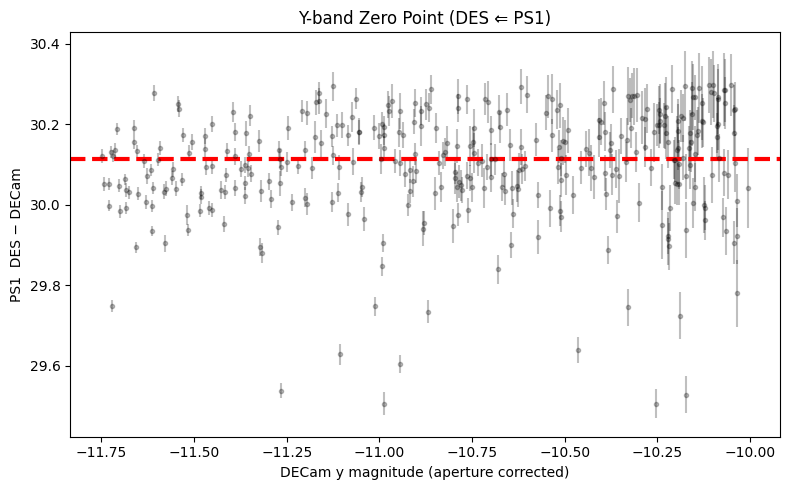

(np.float64(30.064856238746643),
 np.float64(0.007177105640503873),
 np.float64(30.113003873663132),
 np.float64(0.007177105640503873))

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ============================================================
# USER PARAMETERS
# ============================================================
APERTURE_RADIUS = 1.0   # arcsec
SEEING_FWHM     = 0.94  # arcsec

MAG_MIN = -11.75
MAG_MAX = -10

# Correct order
Y_MIN = 29.5
Y_MAX = 30.3

# ============================================================
# Read catalogs
# ============================================================
def read_decam_catalog(filename):
    return pd.read_csv(filename)

def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ============================================================
# Star selection
# ============================================================
def is_star_ps1(ps):
    return np.abs(ps['iPSFMag'] - ps['iKronMag']) < 0.05

# ============================================================
# PS1 helpers
# ============================================================
def ps_col(ps, band):
    return ps[f"{band}PSFMag"].astype(float).values

def ps_err(ps, band):
    return ps[f"{band}PSFMagErr"].astype(float).values

# ============================================================
# PS1 → DES Y transform
# ============================================================
def ps1_to_des_y(ps):

    r = ps_col(ps, 'r')
    i = ps_col(ps, 'i')
    y = ps_col(ps, 'y')

    rerr = ps_err(ps, 'r')
    ierr = ps_err(ps, 'i')
    yerr = ps_err(ps, 'y')

    y_des = y - 0.031 * (r - i) + 0.035
    y_des_err = np.hypot(yerr, 0.031 * np.hypot(rerr, ierr))

    return y_des, y_des_err, (r - i)

# ============================================================
# Aperture correction
# ============================================================
def gaussian_2d(r, sigma):
    return r * np.exp(-r**2 / (2 * sigma**2))

def calculate_k_constant(aperture_radius, seeing_fwhm):

    sigma = seeing_fwhm * gaussian_fwhm_to_sigma

    flux_ap, _  = quad(gaussian_2d, 0, aperture_radius, args=(sigma,))
    flux_tot, _ = quad(gaussian_2d, 0, np.inf, args=(sigma,))

    return flux_tot / flux_ap

def calculate_k_constant_mag(aperture_radius, seeing_fwhm):

    k = calculate_k_constant(aperture_radius, seeing_fwhm)
    return -2.5 * np.log10(k)

# ============================================================
# Main pipeline
# ============================================================
def run_y_band(decam_path, ps_path):

    dec = read_decam_catalog(decam_path)
    ps  = read_ps_catalog(ps_path)

    # ---------------------------
    # Star selection
    # ---------------------------
    star = is_star_ps1(ps)

    dec = dec.loc[star].reset_index(drop=True)
    ps  = ps.loc[star].reset_index(drop=True)

    # ---------------------------
    # DECam mags
    # ---------------------------
    m_aper = dec['MAG_APER'].astype(float).values
    m_err  = dec['MAGERR_APER'].astype(float).values

    # ---------------------------
    # Aperture correction
    # ---------------------------
    aper_corr = calculate_k_constant_mag(APERTURE_RADIUS, SEEING_FWHM)
    m_corr = m_aper + aper_corr

    print(f"Aperture correction applied: {aper_corr:.4f} mag")

    # ---------------------------
    # PS1 → DES Y
    # ---------------------------
    y_des, y_des_err, color = ps1_to_des_y(ps)

    # ---------------------------
    # Total error
    # ---------------------------
    sigma_tot = np.hypot(m_err, y_des_err)

    # ---------------------------
    # Quality cuts
    # ---------------------------
    good = (
        np.isfinite(m_aper) &
        np.isfinite(m_corr) &
        np.isfinite(y_des) &
        np.isfinite(sigma_tot) &
        (ps['yPSFMag'].values > 0) &
        (ps['yPSFMag'].values < 30) &
        (color > -0.4) & (color < 2.4) &
        (dec['FLAGS'].values == 0) &
        (sigma_tot < 0.1)
    )

    m_raw  = m_aper[good]
    m_corr = m_corr[good]
    y_des  = y_des[good]
    err    = sigma_tot[good]

    # ---------------------------
    # Magnitude cut
    # ---------------------------
    mag_range = (m_corr > MAG_MIN) & (m_corr < MAG_MAX)

    m_raw  = m_raw[mag_range]
    m_corr = m_corr[mag_range]
    y_des  = y_des[mag_range]
    err    = err[mag_range]

    print(f"Stars after magnitude cut: {len(m_corr)}")

    # ---------------------------
    # Residuals
    # ---------------------------
    residuals_raw  = y_des - m_raw
    residuals_corr = y_des - m_corr

    # ---------------------------
    # Y-axis cut (29.5–30.3)
    # ---------------------------
    y_mask = (residuals_corr > Y_MIN) & (residuals_corr < Y_MAX)

    m_raw  = m_raw[y_mask]
    m_corr = m_corr[y_mask]
    y_des  = y_des[y_mask]
    err    = err[y_mask]
    residuals_raw  = residuals_raw[y_mask]
    residuals_corr = residuals_corr[y_mask]

    print(f"Stars after Y cut: {len(m_corr)}")

    # ---------------------------
    # Zeropoints
    # ---------------------------
    zp_raw = np.median(residuals_raw)
    zp_raw_err = np.std(residuals_raw) / np.sqrt(len(residuals_raw))

    zp_corr = np.median(residuals_corr)
    zp_corr_err = np.std(residuals_corr) / np.sqrt(len(residuals_corr))

    print("\nY-band Zero Point (DES ⇐ PS1)")
    print(f"ZP (before aperture correction) = {zp_raw:.4f} ± {zp_raw_err:.4f}")
    print(f"ZP (after  aperture correction) = {zp_corr:.4f} ± {zp_corr_err:.4f}")

    # ---------------------------
    # Plot (unchanged)
    # ---------------------------
    plt.figure(figsize=(8,5))
    plt.errorbar(m_corr, residuals_corr, yerr=err, fmt='k.', alpha=0.25)
    plt.axhline(zp_corr, color='r', lw=3, ls='--')
    plt.xlabel("DECam y magnitude (aperture corrected)")
    plt.ylabel("PS1  DES − DECam")
    plt.title("Y-band Zero Point (DES ⇐ PS1)")
    plt.tight_layout()
    plt.show()

    return zp_raw, zp_raw_err, zp_corr, zp_corr_err


# ============================================================
# Run
# ============================================================
Y_DECam = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Y_CDFS_depth_decam_matched.cat"
Y_PS    = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Y_CDFS_depth_panstarrs_matched.csv"

run_y_band(Y_DECam, Y_PS)

Aperture correction (to be applied to ZP): -0.0481 mag
Stars after magnitude cut: 592
Stars after Y cut: 378
-0.0481476349164893

Y-band Zero Point (DES ⇐ PS1)
ZP (raw aperture)        = 30.0807 ± 0.0067
ZP (aperture corrected) = 30.1288 ± 0.0067


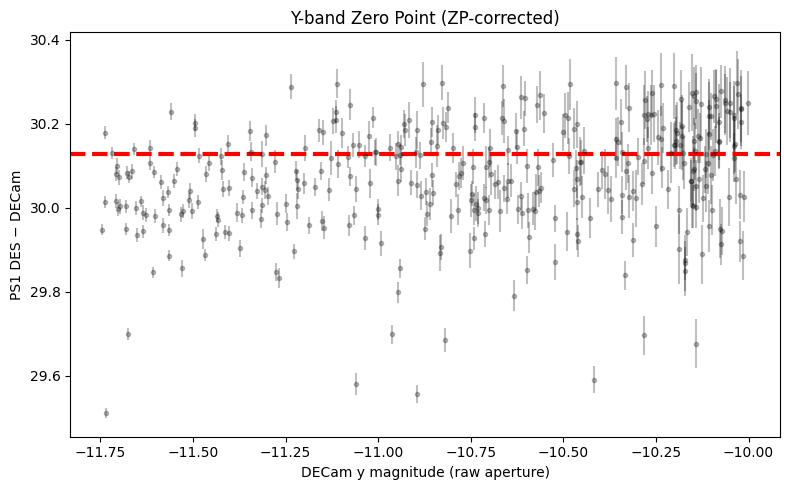

(np.float64(30.080689170455923),
 np.float64(0.006705034413249739),
 np.float64(30.128836805372412),
 np.float64(0.006705034413249739))

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ============================================================
# USER PARAMETERS
# ============================================================
APERTURE_RADIUS = 1.0   # arcsec
SEEING_FWHM     = 0.94  # arcsec

MAG_MIN = -11.75
MAG_MAX = -10

Y_MIN = 29.5
Y_MAX = 30.3

# ============================================================
# Read catalogs
# ============================================================
def read_decam_catalog(filename):
    return pd.read_csv(filename)

def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ============================================================
# Star selection
# ============================================================
def is_star_ps1(ps):
    return np.abs(ps['iPSFMag'] - ps['iKronMag']) < 0.05

# ============================================================
# PS1 helpers
# ============================================================
def ps_col(ps, band):
    return ps[f"{band}PSFMag"].astype(float).values

def ps_err(ps, band):
    return ps[f"{band}PSFMagErr"].astype(float).values

# ============================================================
# PS1 → DES Y transform
# ============================================================
def ps1_to_des_y(ps):

    r = ps_col(ps, 'r')
    i = ps_col(ps, 'i')
    y = ps_col(ps, 'y')

    rerr = ps_err(ps, 'r')
    ierr = ps_err(ps, 'i')
    yerr = ps_err(ps, 'y')

    y_des = y - 0.031 * (r - i) + 0.035
    y_des_err = np.hypot(yerr, 0.031 * np.hypot(rerr, ierr))

    return y_des, y_des_err, (r - i)

# ============================================================
# Aperture correction
# ============================================================
def gaussian_2d(r, sigma):
    return r * np.exp(-r**2 / (2 * sigma**2))

def calculate_k_constant(aperture_radius, seeing_fwhm):

    sigma = seeing_fwhm * gaussian_fwhm_to_sigma

    flux_ap, _  = quad(gaussian_2d, 0, aperture_radius, args=(sigma,))
    flux_tot, _ = quad(gaussian_2d, 0, np.inf, args=(sigma,))

    return flux_tot / flux_ap

def calculate_k_constant_mag(aperture_radius, seeing_fwhm):

    k = calculate_k_constant(aperture_radius, seeing_fwhm)
    return -2.5 * np.log10(k)

# ============================================================
# Main pipeline
# ============================================================
def run_y_band(decam_path, ps_path):

    dec = read_decam_catalog(decam_path)
    ps  = read_ps_catalog(ps_path)

    # ---------------------------
    # Star selection
    # ---------------------------
    star = is_star_ps1(ps)

    dec = dec.loc[star].reset_index(drop=True)
    ps  = ps.loc[star].reset_index(drop=True)

    # ---------------------------
    # DECam mags (RAW only)
    # ---------------------------
    m_aper = dec['MAG_APER'].astype(float).values
    m_err  = dec['MAGERR_APER'].astype(float).values

    # ---------------------------
    # Aperture correction (for ZP later)
    # ---------------------------
    aper_corr = calculate_k_constant_mag(APERTURE_RADIUS, SEEING_FWHM)
    print(f"Aperture correction (to be applied to ZP): {aper_corr:.4f} mag")

    # ---------------------------
    # PS1 → DES Y
    # ---------------------------
    y_des, y_des_err, color = ps1_to_des_y(ps)

    # ---------------------------
    # Total error
    # ---------------------------
    sigma_tot = np.hypot(m_err, y_des_err)

    # ---------------------------
    # Quality cuts
    # ---------------------------
    good = (
        np.isfinite(m_aper) &
        np.isfinite(y_des) &
        np.isfinite(sigma_tot) &
        (ps['yPSFMag'].values > 0) &
        (ps['yPSFMag'].values < 30) &
        (color > -0.4) & (color < 2.4) &
        (dec['FLAGS'].values == 0) &
        (sigma_tot < 0.1)
    )

    m_raw = m_aper[good]
    y_des = y_des[good]
    err   = sigma_tot[good]

    # ---------------------------
    # Magnitude cut (on RAW mags)
    # ---------------------------
    mag_range = (m_raw > MAG_MIN) & (m_raw < MAG_MAX)

    m_raw = m_raw[mag_range]
    y_des = y_des[mag_range]
    err   = err[mag_range]

    print(f"Stars after magnitude cut: {len(m_raw)}")

    # ---------------------------
    # Residuals (RAW)
    # ---------------------------
    residuals_raw = y_des - m_raw

    # ---------------------------
    # Y-axis cut
    # ---------------------------
    y_mask = (residuals_raw > Y_MIN) & (residuals_raw < Y_MAX)

    m_raw = m_raw[y_mask]
    y_des = y_des[y_mask]
    err   = err[y_mask]
    residuals_raw = residuals_raw[y_mask]

    print(f"Stars after Y cut: {len(m_raw)}")

    # ---------------------------
    # Zeropoint (RAW)
    # ---------------------------
    zp_raw = np.median(residuals_raw)
    zp_raw_err = np.std(residuals_raw) / np.sqrt(len(residuals_raw))

    # ---------------------------
    # Apply aperture correction to ZP
    # ---------------------------
    zp_final = zp_raw - aper_corr
    print(aper_corr)
    zp_final_err = zp_raw_err

    print("\nY-band Zero Point (DES ⇐ PS1)")
    print(f"ZP (raw aperture)        = {zp_raw:.4f} ± {zp_raw_err:.4f}")
    print(f"ZP (aperture corrected) = {zp_final:.4f} ± {zp_final_err:.4f}")

    # ---------------------------
    # Plot (use RAW mags!)
    # ---------------------------
    plt.figure(figsize=(8,5))
    plt.errorbar(m_raw, residuals_raw, yerr=err, fmt='k.', alpha=0.25)
    plt.axhline(zp_final, color='r', lw=3, ls='--')
    plt.xlabel("DECam y magnitude (raw aperture)")
    plt.ylabel("PS1 DES − DECam")
    plt.title("Y-band Zero Point (ZP-corrected)")
    plt.tight_layout()
    plt.show()

    return zp_raw, zp_raw_err, zp_final, zp_final_err


# ============================================================
# Run
# ============================================================
Y_DECam = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Y_CDFS_depth_decam_matched.cat"
Y_PS    = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Y_CDFS_depth_panstarrs_matched.csv"

run_y_band(Y_DECam, Y_PS)

Aperture correction applied: -0.0481 mag
Stars after magnitude cut: 627
Stars after Y cut: 276

Y-band Zero Point (DES ⇐ PS1)
ZP (before aperture correction) = 30.1982 ± 0.0082
ZP (after  aperture correction) = 30.1500 ± 0.0082


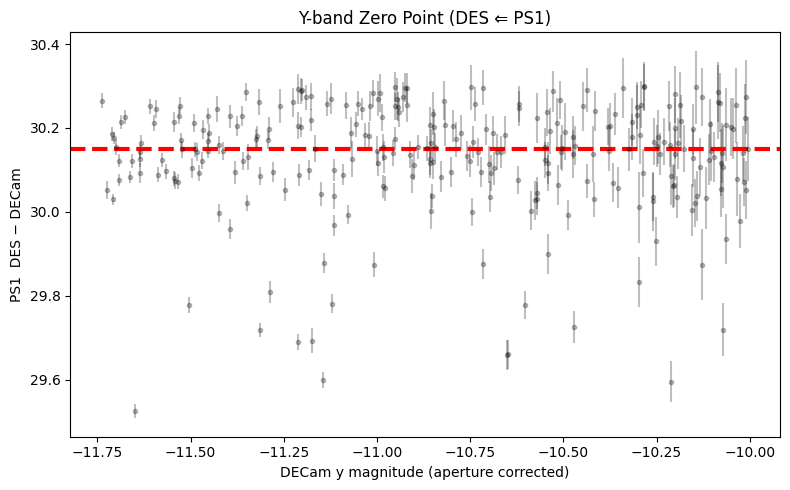

(np.float64(30.1981513599396),
 np.float64(0.008247558967836114),
 np.float64(30.15000372502311),
 np.float64(0.008247558967836114))

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ============================================================
# USER PARAMETERS
# ============================================================
APERTURE_RADIUS = 1.0   # arcsec
SEEING_FWHM     = 0.94  # arcsec

MAG_MIN = -11.75
MAG_MAX = -10

# Correct order
Y_MIN = 29.5
Y_MAX = 30.3

# ============================================================
# Read catalogs
# ============================================================
def read_decam_catalog(filename):
    return pd.read_csv(filename)

def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ============================================================
# Star selection
# ============================================================
def is_star_ps1(ps):
    return np.abs(ps['iPSFMag'] - ps['iKronMag']) < 0.05

# ============================================================
# PS1 helpers
# ============================================================
def ps_col(ps, band):
    return ps[f"{band}PSFMag"].astype(float).values

def ps_err(ps, band):
    return ps[f"{band}PSFMagErr"].astype(float).values

# ============================================================
# PS1 → DES Y transform
# ============================================================
def ps1_to_des_y(ps):

    r = ps_col(ps, 'r')
    i = ps_col(ps, 'i')
    y = ps_col(ps, 'y')

    rerr = ps_err(ps, 'r')
    ierr = ps_err(ps, 'i')
    yerr = ps_err(ps, 'y')

    y_des = y - 0.031 * (r - i) + 0.035
    y_des_err = np.hypot(yerr, 0.031 * np.hypot(rerr, ierr))

    return y_des, y_des_err, (r - i)

# ============================================================
# Aperture correction
# ============================================================
def gaussian_2d(r, sigma):
    return r * np.exp(-r**2 / (2 * sigma**2))

def calculate_k_constant(aperture_radius, seeing_fwhm):

    sigma = seeing_fwhm * gaussian_fwhm_to_sigma

    flux_ap, _  = quad(gaussian_2d, 0, aperture_radius, args=(sigma,))
    flux_tot, _ = quad(gaussian_2d, 0, np.inf, args=(sigma,))

    return flux_tot / flux_ap

def calculate_k_constant_mag(aperture_radius, seeing_fwhm):

    k = calculate_k_constant(aperture_radius, seeing_fwhm)
    return -2.5 * np.log10(k)

# ============================================================
# Main pipeline
# ============================================================
def run_y_band(decam_path, ps_path):

    dec = read_decam_catalog(decam_path)
    ps  = read_ps_catalog(ps_path)

    # ---------------------------
    # Star selection
    # ---------------------------
    star = is_star_ps1(ps)

    dec = dec.loc[star].reset_index(drop=True)
    ps  = ps.loc[star].reset_index(drop=True)

    # ---------------------------
    # DECam mags
    # ---------------------------
    m_aper = dec['MAG_AUTO'].astype(float).values
    m_err  = dec['MAGERR_AUTO'].astype(float).values

    # ---------------------------
    # Aperture correction
    # ---------------------------
    aper_corr = calculate_k_constant_mag(APERTURE_RADIUS, SEEING_FWHM)

    m_corr = m_aper - aper_corr

    print(f"Aperture correction applied: {aper_corr:.4f} mag")

    # ---------------------------
    # PS1 → DES Y
    # ---------------------------
    y_des, y_des_err, color = ps1_to_des_y(ps)

    # ---------------------------
    # Total error
    # ---------------------------
    sigma_tot = np.hypot(m_err, y_des_err)

    # ---------------------------
    # Quality cuts
    # ---------------------------
    good = (
        np.isfinite(m_aper) &
        np.isfinite(m_corr) &
        np.isfinite(y_des) &
        np.isfinite(sigma_tot) &
        (ps['yPSFMag'].values > 0) &
        (ps['yPSFMag'].values < 30) &
        (color > -0.4) & (color < 2.4) &
        (dec['FLAGS'].values == 0) &
        (sigma_tot < 0.1)
    )

    m_raw  = m_aper[good]
    m_corr = m_corr[good]
    y_des  = y_des[good]
    err    = sigma_tot[good]

    # ---------------------------
    # Magnitude cut
    # ---------------------------
    mag_range = (m_corr > MAG_MIN) & (m_corr < MAG_MAX)

    m_raw  = m_raw[mag_range]
    m_corr = m_corr[mag_range]
    y_des  = y_des[mag_range]
    err    = err[mag_range]

    print(f"Stars after magnitude cut: {len(m_corr)}")

    # ---------------------------
    # Residuals
    # ---------------------------
    residuals_raw  = y_des - m_raw
    residuals_corr = y_des - m_corr

    # ---------------------------
    # Y-axis cut (29.5–30.3)
    # ---------------------------
    y_mask = (residuals_corr > Y_MIN) & (residuals_corr < Y_MAX)

    m_raw  = m_raw[y_mask]
    m_corr = m_corr[y_mask]
    y_des  = y_des[y_mask]
    err    = err[y_mask]
    residuals_raw  = residuals_raw[y_mask]
    residuals_corr = residuals_corr[y_mask]

    print(f"Stars after Y cut: {len(m_corr)}")

    # ---------------------------
    # Zeropoints
    # ---------------------------
    zp_raw = np.median(residuals_raw)
    zp_raw_err = np.std(residuals_raw) / np.sqrt(len(residuals_raw))

    zp_corr = np.median(residuals_corr)
    zp_corr_err = np.std(residuals_corr) / np.sqrt(len(residuals_corr))

    print("\nY-band Zero Point (DES ⇐ PS1)")
    print(f"ZP (before aperture correction) = {zp_raw:.4f} ± {zp_raw_err:.4f}")
    print(f"ZP (after  aperture correction) = {zp_corr:.4f} ± {zp_corr_err:.4f}")

    # ---------------------------
    # Plot (unchanged)
    # ---------------------------
    plt.figure(figsize=(8,5))
    plt.errorbar(m_corr, residuals_corr, yerr=err, fmt='k.', alpha=0.25)
    plt.axhline(zp_corr, color='r', lw=3, ls='--')
    plt.xlabel("DECam y magnitude (aperture corrected)")
    plt.ylabel("PS1  DES − DECam")
    plt.title("Y-band Zero Point (DES ⇐ PS1)")
    plt.tight_layout()
    plt.show()

    return zp_raw, zp_raw_err, zp_corr, zp_corr_err


# ============================================================
# Run
# ============================================================
Y_DECam = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Y_CDFS_depth_decam_matched.cat"
Y_PS    = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Y_CDFS_depth_panstarrs_matched.csv"

run_y_band(Y_DECam, Y_PS)


--- i-band ---
i-band: stars selected = 8661
i-band ZP = 31.349 ± 0.003


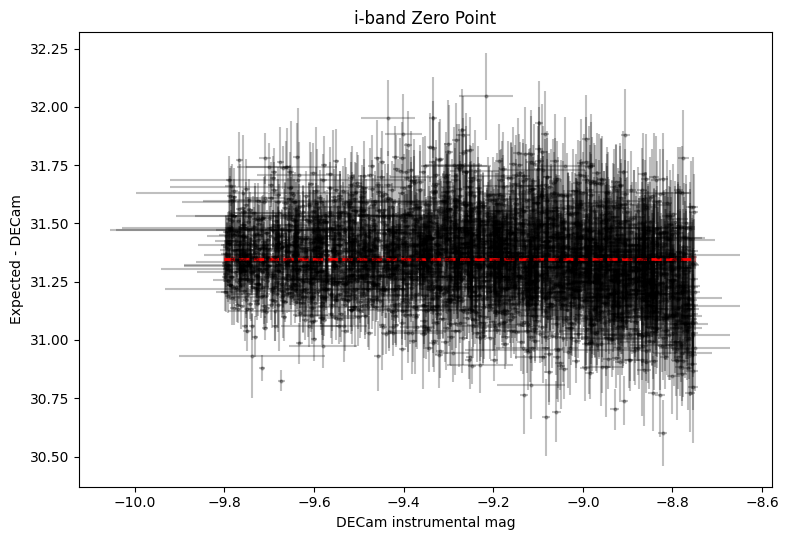


--- z-band ---
z-band: stars selected = 8527
z-band ZP = 31.509 ± 0.003


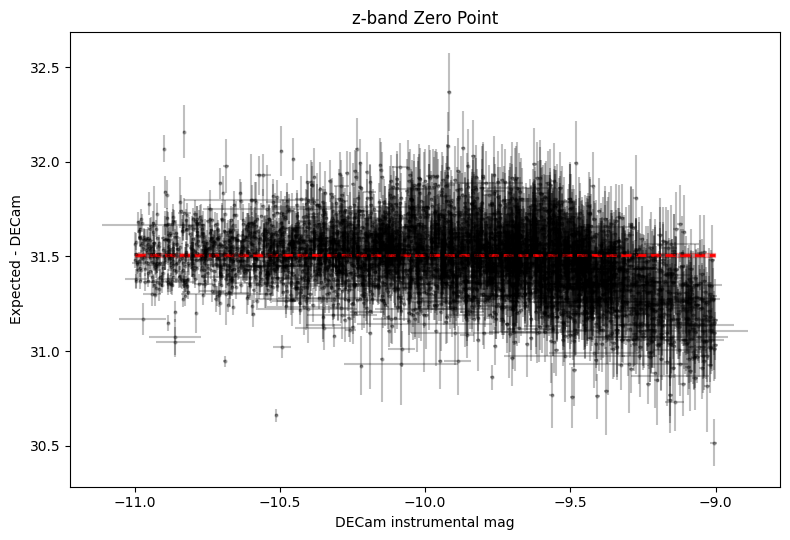

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import ArrayLike
from astropy.stats import sigma_clip

# ============================================================
# Read DECam Catalog
# ============================================================
def read_decam_catalog(filename: str) -> pd.DataFrame:
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ============================================================
# Read Pan-STARRS Catalog
# ============================================================
def read_ps_catalog(filename: str) -> pd.DataFrame:
    return pd.read_csv(filename)

# ============================================================
# Star Selection (PSF - Kron)
# ============================================================
def is_star_ps1(ps_df: pd.DataFrame, band: str = 'i', threshold: float = 0.05) -> ArrayLike:
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    if psf_col not in ps_df.columns or kron_col not in ps_df.columns:
        raise ValueError(f"Missing columns: {psf_col} or {kron_col}")
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag.values) < threshold

# ============================================================
# Robust column getter
# ============================================================
def _col(ps: pd.DataFrame, base: str, kind: str = "mag") -> np.ndarray:
    if kind == "mag":
        candidates = [f"{base}PSFMag", f"{base}MeanPSFMag"]
    else:
        candidates = [f"{base}PSFMagErr", f"{base}MeanPSFMagErr"]

    for c in candidates:
        if c in ps.columns:
            return ps[c].values.astype(float)

    if kind == "mag":
        raise KeyError(f"No PS1 mag column found for {base}")
    return np.full(len(ps), 0.02, dtype=float)

# ============================================================
# PS1 → DECam transforms
# ============================================================
def convert_panstars_i_dec_mags(ps: pd.DataFrame):
    rPSF = _col(ps, 'r', 'mag')
    iPSF = _col(ps, 'i', 'mag')
    rErr = _col(ps, 'r', 'err')
    iErr = _col(ps, 'i', 'err')

    i_dec = iPSF - 0.155 * (rPSF - iPSF) + 0.015
    i_dec_err = np.hypot(iErr, 0.155 * np.hypot(iErr, rErr))
    return i_dec, i_dec_err

def convert_panstars_z_dec_mags(ps: pd.DataFrame):
    rPSF = _col(ps, 'r', 'mag')
    iPSF = _col(ps, 'i', 'mag')
    zPSF = _col(ps, 'z', 'mag')
    rErr = _col(ps, 'r', 'err')
    iErr = _col(ps, 'i', 'err')
    zErr = _col(ps, 'z', 'err')

    z_dec = zPSF - 0.114 * (rPSF - iPSF) - 0.010
    z_dec_err = np.hypot(zErr, 0.114 * np.hypot(iErr, rErr))
    return z_dec, z_dec_err

# ============================================================
# Prepare magnitudes
# ============================================================
def prepare_mags(decam_df: pd.DataFrame, ps_df: pd.DataFrame, band: str):
    dec_mags = decam_df['MAG_APER'].values.astype(float)
    dec_errs = decam_df['MAGERR_APER'].values.astype(float)

    if band == 'i':
        exp_mags, exp_errs = convert_panstars_i_dec_mags(ps_df)
    elif band == 'z':
        exp_mags, exp_errs = convert_panstars_z_dec_mags(ps_df)
    else:
        raise ValueError("band must be 'i' or 'z'.")

    return dec_mags, dec_errs, exp_mags, exp_errs

# ============================================================
# Clean and quality cuts
# ============================================================
def apply_basic_cuts(dec_mags, dec_errs, exp_mags, exp_errs):

    mask = (
        np.isfinite(dec_mags) &
        np.isfinite(exp_mags) &
        (dec_errs < 0.3) &
        (exp_errs < 0.3) &
        (dec_mags > -20) &
        (dec_mags < 5) &
        (exp_mags > 10) &
        (exp_mags < 30)
    )

    return dec_mags[mask], dec_errs[mask], exp_mags[mask], exp_errs[mask]

# ============================================================
# Robust Zero Point Fit
# ============================================================
def fit_zero_point(dec_mags, exp_mags):

    residuals = exp_mags - dec_mags

    lo, hi = np.percentile(dec_mags, [10, 90])
    mag_mask = (dec_mags > lo) & (dec_mags < hi)
    residuals = residuals[mag_mask]

    if len(residuals) < 10:
        raise RuntimeError("Not enough stars after percentile cut to compute ZP.")

    clipped = sigma_clip(residuals, sigma=3, maxiters=5)
    good = ~clipped.mask
    residuals = residuals[good]

    zpt = np.median(residuals)
    scatter = np.std(residuals)
    zpt_err = scatter / np.sqrt(len(residuals))

    return zpt, zpt_err, residuals

# ============================================================
# Plot
# ============================================================
def plot_zpt(dec_mags, dec_errs, exp_mags, exp_errs, band, zpt, zpt_err):

    y = exp_mags - dec_mags
    y_err = np.hypot(dec_errs, exp_errs)

    plt.figure(figsize=(8,5.5))
    plt.errorbar(
        dec_mags, y,
        xerr=dec_errs, yerr=y_err,
        fmt='ko', alpha=0.25, ms=2
    )

    x = np.linspace(np.min(dec_mags), np.max(dec_mags), 200)
    plt.plot(x, np.ones_like(x)*zpt, 'r--', lw=2)
    plt.fill_between(x,
                     zpt - 3*zpt_err,
                     zpt + 3*zpt_err,
                     color='r', alpha=0.3)

    plt.xlabel("DECam instrumental mag")
    plt.ylabel("Expected - DECam")
    plt.title(f"{band}-band Zero Point")
    plt.tight_layout()
    plt.show()

# ============================================================
# Run per band
# ============================================================
def run_band(decam_path: str, ps_path: str, band: str):

    decam_df = read_decam_catalog(decam_path)
    ps_df = read_ps_catalog(ps_path)

    star_mask = is_star_ps1(ps_df, band=band, threshold=0.05)

    decam_df = decam_df[star_mask].reset_index(drop=True)
    ps_df = ps_df[star_mask].reset_index(drop=True)

    print(f"{band}-band: stars selected = {len(decam_df)}")

    dec_mags, dec_errs, exp_mags, exp_errs = prepare_mags(decam_df, ps_df, band)
    dec_mags, dec_errs, exp_mags, exp_errs = apply_basic_cuts(
        dec_mags, dec_errs, exp_mags, exp_errs
    )

    # =========================
    # BAND-SPECIFIC MAG CUT
    # =========================
    if band == 'i':
        mag_mask = (dec_mags > -9.8) & (dec_mags < -8.75) 
    elif band == 'z':
        mag_mask = (dec_mags > -11) & (dec_mags < -9)

    dec_mags = dec_mags[mag_mask]
    dec_errs = dec_errs[mag_mask]
    exp_mags = exp_mags[mag_mask]
    exp_errs = exp_errs[mag_mask]

    if len(dec_mags) < 10:
        raise RuntimeError(f"Not enough stars after cuts for {band}-band.")

    zpt, zpt_err, _ = fit_zero_point(dec_mags, exp_mags)

    print(f"{band}-band ZP = {zpt:.3f} ± {zpt_err:.3f}")

    plot_zpt(dec_mags, dec_errs, exp_mags, exp_errs, band, zpt, zpt_err)

    return zpt, zpt_err

# ============================================================
# Main
# ============================================================
if __name__ == "__main__":

    I_DECam = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_decam_matched.cat"
    I_PS    = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_panstarrs_matched.csv"

    Z_DECam = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Z_CDFS_depth_decam_matched.cat"
    Z_PS    = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Z_CDFS_depth_panstarrs_matched.csv"

    print("\n--- i-band ---")
    try:
        run_band(I_DECam, I_PS, band='i')
    except Exception as e:
        print(f"i-band error: {e}")

    print("\n--- z-band ---")
    try:
        run_band(Z_DECam, Z_PS, band='z')
    except Exception as e:
        print(f"z-band error: {e}")

# TRIAL


--- i-band ---
i-band: stars selected = 8661
i-band RAW aperture ZP = 31.349 ± 0.003
i-band aperture correction = -0.1711 mag (FWHM = 1.20")
i-band CORRECTED ZP = 31.520 ± 0.003
Shift due to aperture correction = 0.1711 mag


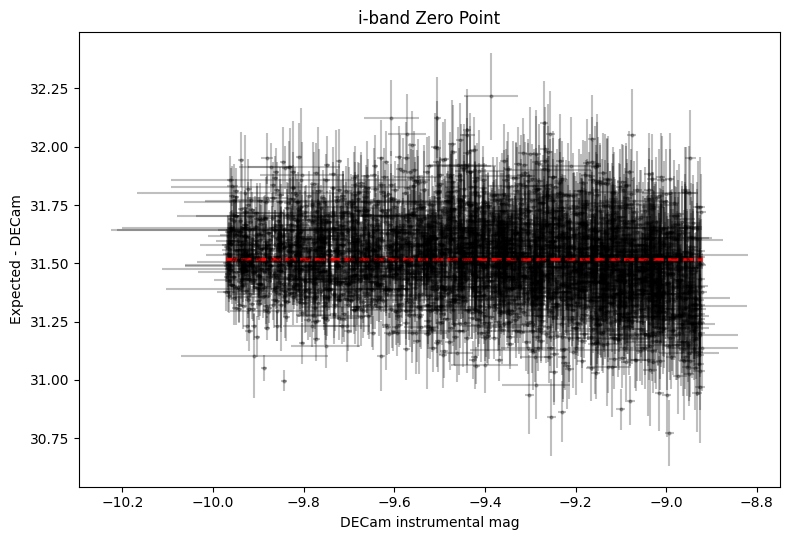


--- z-band ---
z-band: stars selected = 8527
z-band RAW aperture ZP = 31.509 ± 0.003
z-band aperture correction = -0.1424 mag (FWHM = 1.15")
z-band CORRECTED ZP = 31.651 ± 0.003
Shift due to aperture correction = 0.1424 mag


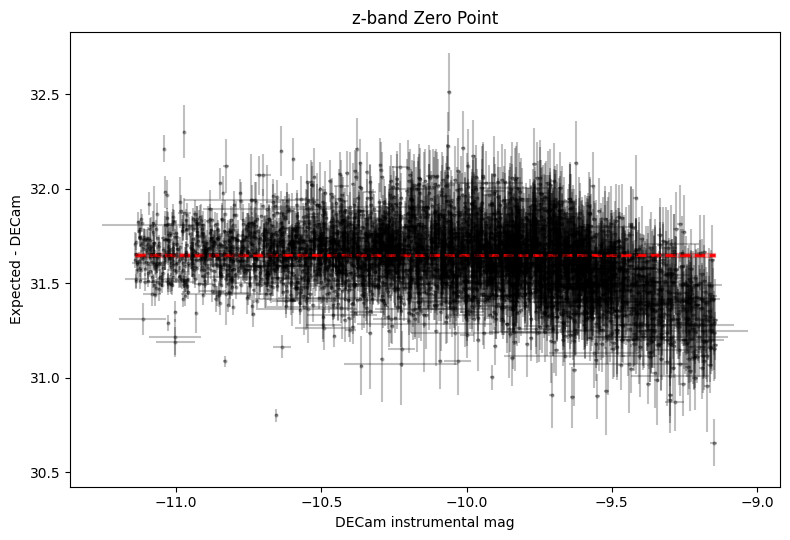

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import ArrayLike
from astropy.stats import sigma_clip


APERTURE_RADIUS = 1.0   # arcsec
SEEING = {
    "i": 1.20,
    "z": 1.15,
}


def read_decam_catalog(filename: str) -> pd.DataFrame:
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

def gaussian_2d(r, sigma):
    return r * np.exp(-r**2 / (2 * sigma**2))

def calculate_k_constant_mag(aperture_radius, seeing_fwhm):
    sigma = seeing_fwhm * gaussian_fwhm_to_sigma
    flux_ap, _  = quad(gaussian_2d, 0, aperture_radius, args=(sigma,))
    flux_tot, _ = quad(gaussian_2d, 0, np.inf, args=(sigma,))
    return -2.5 * np.log10(flux_tot / flux_ap)


def read_ps_catalog(filename: str) -> pd.DataFrame:
    return pd.read_csv(filename)


def is_star_ps1(ps_df: pd.DataFrame, band: str = 'i', threshold: float = 0.05) -> ArrayLike:
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    if psf_col not in ps_df.columns or kron_col not in ps_df.columns:
        raise ValueError(f"Missing columns: {psf_col} or {kron_col}")
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag.values) < threshold


def _col(ps: pd.DataFrame, base: str, kind: str = "mag") -> np.ndarray:
    if kind == "mag":
        candidates = [f"{base}PSFMag", f"{base}MeanPSFMag"]
    else:
        candidates = [f"{base}PSFMagErr", f"{base}MeanPSFMagErr"]

    for c in candidates:
        if c in ps.columns:
            return ps[c].values.astype(float)

    if kind == "mag":
        raise KeyError(f"No PS1 mag column found for {base}")
    return np.full(len(ps), 0.02, dtype=float)


def convert_panstars_i_dec_mags(ps: pd.DataFrame):
    rPSF = _col(ps, 'r', 'mag')
    iPSF = _col(ps, 'i', 'mag')
    rErr = _col(ps, 'r', 'err')
    iErr = _col(ps, 'i', 'err')

    i_dec = iPSF - 0.155 * (rPSF - iPSF) + 0.015
    i_dec_err = np.hypot(iErr, 0.155 * np.hypot(iErr, rErr))
    return i_dec, i_dec_err

def convert_panstars_z_dec_mags(ps: pd.DataFrame):
    rPSF = _col(ps, 'r', 'mag')
    iPSF = _col(ps, 'i', 'mag')
    zPSF = _col(ps, 'z', 'mag')
    rErr = _col(ps, 'r', 'err')
    iErr = _col(ps, 'i', 'err')
    zErr = _col(ps, 'z', 'err')

    z_dec = zPSF - 0.114 * (rPSF - iPSF) - 0.010
    z_dec_err = np.hypot(zErr, 0.114 * np.hypot(iErr, rErr))
    return z_dec, z_dec_err


def prepare_mags(decam_df: pd.DataFrame, ps_df: pd.DataFrame, band: str):
    dec_mags = decam_df['MAG_APER'].values.astype(float)
    dec_errs = decam_df['MAGERR_APER'].values.astype(float)

    if band == 'i':
        exp_mags, exp_errs = convert_panstars_i_dec_mags(ps_df)
    elif band == 'z':
        exp_mags, exp_errs = convert_panstars_z_dec_mags(ps_df)
    else:
        raise ValueError("band must be 'i' or 'z'.")

    return dec_mags, dec_errs, exp_mags, exp_errs


def apply_basic_cuts(dec_mags, dec_errs, exp_mags, exp_errs):

    mask = (
        np.isfinite(dec_mags) &
        np.isfinite(exp_mags) &
        (dec_errs < 0.3) &
        (exp_errs < 0.3) &
        (dec_mags > -20) &
        (dec_mags < 5) &
        (exp_mags > 10) &
        (exp_mags < 30)
    )

    return dec_mags[mask], dec_errs[mask], exp_mags[mask], exp_errs[mask]


def fit_zero_point(dec_mags, exp_mags):

    residuals = exp_mags - dec_mags

    lo, hi = np.percentile(dec_mags, [10, 90])
    mag_mask = (dec_mags > lo) & (dec_mags < hi)
    residuals = residuals[mag_mask]

    if len(residuals) < 10:
        raise RuntimeError("Not enough stars after percentile cut to compute ZP.")

    clipped = sigma_clip(residuals, sigma=3, maxiters=5)
    good = ~clipped.mask
    residuals = residuals[good]

    zpt = np.median(residuals)
    scatter = np.std(residuals)
    zpt_err = scatter / np.sqrt(len(residuals))

    return zpt, zpt_err, residuals


def plot_zpt(dec_mags, dec_errs, exp_mags, exp_errs, band, zpt, zpt_err):

    y = exp_mags - dec_mags
    y_err = np.hypot(dec_errs, exp_errs)

    plt.figure(figsize=(8,5.5))
    plt.errorbar(
        dec_mags, y,
        xerr=dec_errs, yerr=y_err,
        fmt='ko', alpha=0.25, ms=2
    )

    x = np.linspace(np.min(dec_mags), np.max(dec_mags), 200)
    plt.plot(x, np.ones_like(x)*zpt, 'r--', lw=2)
    plt.fill_between(x,
                     zpt - 3*zpt_err,
                     zpt + 3*zpt_err,
                     color='r', alpha=0.3)

    plt.xlabel("DECam instrumental mag")
    plt.ylabel("Expected - DECam")
    plt.title(f"{band}-band Zero Point")
    plt.tight_layout()
    plt.show()


def run_band(decam_path: str, ps_path: str, band: str):

    decam_df = read_decam_catalog(decam_path)
    ps_df = read_ps_catalog(ps_path)

    
    star_mask = is_star_ps1(ps_df, band=band, threshold=0.05)

    decam_df = decam_df[star_mask].reset_index(drop=True)
    ps_df = ps_df[star_mask].reset_index(drop=True)

    print(f"{band}-band: stars selected = {len(decam_df)}")

   
    dec_mags_raw, dec_errs, exp_mags, exp_errs = prepare_mags(
        decam_df, ps_df, band
    )

    dec_mags_raw, dec_errs, exp_mags, exp_errs = apply_basic_cuts(
        dec_mags_raw, dec_errs, exp_mags, exp_errs
    )

    # Band window
    if band == 'i':
        mag_mask = (dec_mags_raw > -9.8) & (dec_mags_raw < -8.75)
    elif band == 'z':
        mag_mask = (dec_mags_raw > -11) & (dec_mags_raw < -9)

    dec_mags_raw = dec_mags_raw[mag_mask]
    dec_errs = dec_errs[mag_mask]
    exp_mags = exp_mags[mag_mask]
    exp_errs = exp_errs[mag_mask]

    zpt_raw, zpt_raw_err, _ = fit_zero_point(dec_mags_raw, exp_mags)

    print(f"{band}-band RAW aperture ZP = {zpt_raw:.3f} ± {zpt_raw_err:.3f}")

    
    seeing_fwhm = SEEING[band]
    aper_corr = calculate_k_constant_mag(APERTURE_RADIUS, seeing_fwhm)

    print(
        f"{band}-band aperture correction = {aper_corr:.4f} mag "
        f"(FWHM = {seeing_fwhm:.2f}\")"
    )

    dec_mags_corr = dec_mags_raw + aper_corr

    zpt_corr, zpt_corr_err, _ = fit_zero_point(dec_mags_corr, exp_mags)

    print(f"{band}-band CORRECTED ZP = {zpt_corr:.3f} ± {zpt_corr_err:.3f}")

    print(
        f"Shift due to aperture correction = "
        f"{zpt_corr - zpt_raw:.4f} mag"
    )

    # Plot corrected version
    plot_zpt(dec_mags_corr, dec_errs, exp_mags, exp_errs,
             band, zpt_corr, zpt_corr_err)

    return zpt_corr, zpt_corr_err

    


if __name__ == "__main__":

    I_DECam = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_decam_matched.cat"
    I_PS    = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_panstarrs_matched.csv"

    Z_DECam = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Z_CDFS_depth_decam_matched.cat"
    Z_PS    = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Z_CDFS_depth_panstarrs_matched.csv"

    print("\n--- i-band ---")
    
    try:
        run_band(I_DECam, I_PS, band='i')
    except Exception as e:
        print(f"i-band error: {e}")

    print("\n--- z-band ---")
    try:
        run_band(Z_DECam, Z_PS, band='z')
    except Exception as e:
        print(f"z-band error: {e}")



--- i-band ---
i-band: stars selected = 8661
i-band RAW ZP = 31.349 ± 0.003
i-band aperture correction = -0.1711 mag
i-band FINAL ZP = 31.520 ± 0.003
Shift = 0.1711 mag


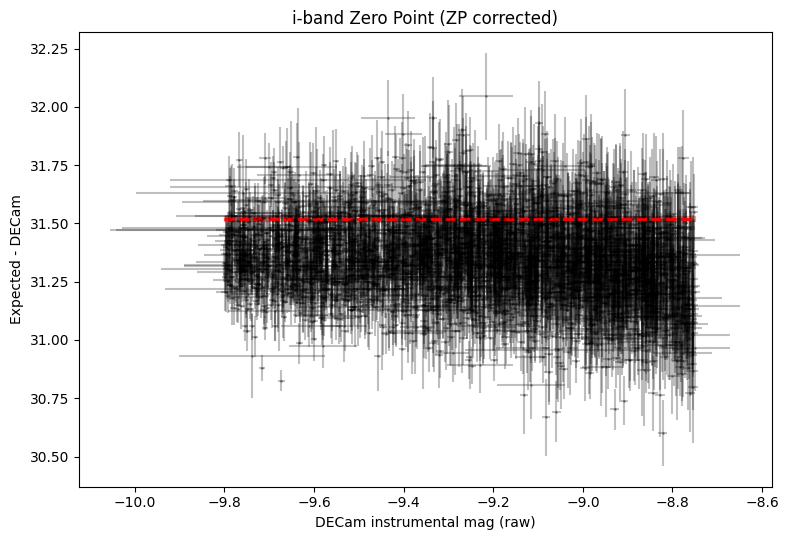


--- z-band ---
z-band: stars selected = 8527
z-band RAW ZP = 31.524 ± 0.003
z-band aperture correction = -0.1424 mag
z-band FINAL ZP = 31.667 ± 0.003
Shift = 0.1424 mag


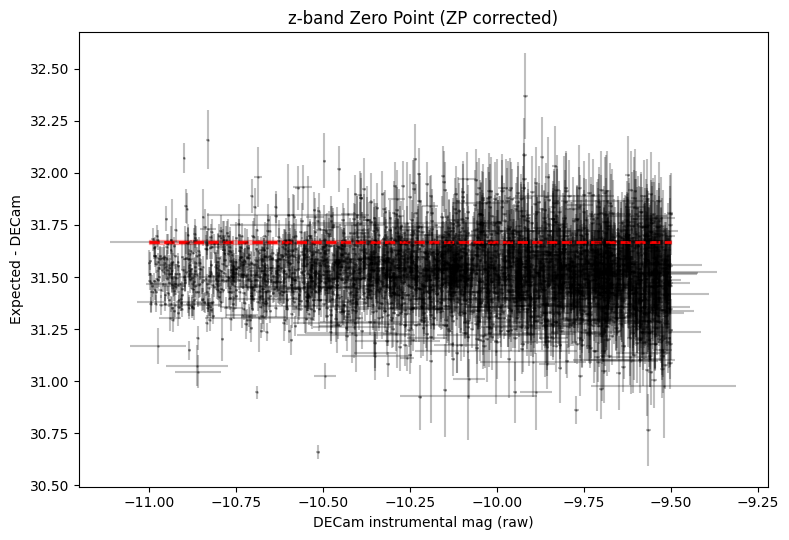

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import ArrayLike
from astropy.stats import sigma_clip, gaussian_fwhm_to_sigma
from scipy.integrate import quad


APERTURE_RADIUS = 1.0   # arcsec
SEEING = {
    "i": 1.20,
    "z": 1.15,
}


# ============================================================
# I/O
# ============================================================
def read_decam_catalog(filename: str) -> pd.DataFrame:
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

def read_ps_catalog(filename: str) -> pd.DataFrame:
    return pd.read_csv(filename)


# ============================================================
# Aperture correction
# ============================================================
def gaussian_2d(r, sigma):
    return r * np.exp(-r**2 / (2 * sigma**2))

def calculate_k_constant_mag(aperture_radius, seeing_fwhm):
    sigma = seeing_fwhm * gaussian_fwhm_to_sigma
    flux_ap, _  = quad(gaussian_2d, 0, aperture_radius, args=(sigma,))
    flux_tot, _ = quad(gaussian_2d, 0, np.inf, args=(sigma,))
    return -2.5 * np.log10(flux_tot / flux_ap)


# ============================================================
# Star selection
# ============================================================
def is_star_ps1(ps_df: pd.DataFrame, band: str = 'i', threshold: float = 0.05) -> ArrayLike:
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"

    if psf_col not in ps_df.columns or kron_col not in ps_df.columns:
        raise ValueError(f"Missing columns: {psf_col} or {kron_col}")

    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag.values) < threshold


# ============================================================
# PS1 helpers
# ============================================================
def _col(ps: pd.DataFrame, base: str, kind: str = "mag") -> np.ndarray:
    if kind == "mag":
        candidates = [f"{base}PSFMag", f"{base}MeanPSFMag"]
    else:
        candidates = [f"{base}PSFMagErr", f"{base}MeanPSFMagErr"]

    for c in candidates:
        if c in ps.columns:
            return ps[c].values.astype(float)

    if kind == "mag":
        raise KeyError(f"No PS1 mag column found for {base}")
    return np.full(len(ps), 0.02, dtype=float)


# ============================================================
# PS1 → DECam transforms
# ============================================================
def convert_panstars_i_dec_mags(ps: pd.DataFrame):
    rPSF = _col(ps, 'r', 'mag')
    iPSF = _col(ps, 'i', 'mag')
    rErr = _col(ps, 'r', 'err')
    iErr = _col(ps, 'i', 'err')

    i_dec = iPSF - 0.155 * (rPSF - iPSF) + 0.015
    i_dec_err = np.hypot(iErr, 0.155 * np.hypot(iErr, rErr))
    return i_dec, i_dec_err

def convert_panstars_z_dec_mags(ps: pd.DataFrame):
    rPSF = _col(ps, 'r', 'mag')
    iPSF = _col(ps, 'i', 'mag')
    zPSF = _col(ps, 'z', 'mag')
    rErr = _col(ps, 'r', 'err')
    iErr = _col(ps, 'i', 'err')
    zErr = _col(ps, 'z', 'err')

    z_dec = zPSF - 0.114 * (rPSF - iPSF) - 0.010
    z_dec_err = np.hypot(zErr, 0.114 * np.hypot(iErr, rErr))
    return z_dec, z_dec_err


# ============================================================
# Prepare mags
# ============================================================
def prepare_mags(decam_df: pd.DataFrame, ps_df: pd.DataFrame, band: str):

    dec_mags = decam_df['MAG_APER'].values.astype(float)
    dec_errs = decam_df['MAGERR_APER'].values.astype(float)

    if band == 'i':
        exp_mags, exp_errs = convert_panstars_i_dec_mags(ps_df)
    elif band == 'z':
        exp_mags, exp_errs = convert_panstars_z_dec_mags(ps_df)
    else:
        raise ValueError("band must be 'i' or 'z'.")

    return dec_mags, dec_errs, exp_mags, exp_errs


# ============================================================
# Cuts
# ============================================================
def apply_basic_cuts(dec_mags, dec_errs, exp_mags, exp_errs):

    mask = (
        np.isfinite(dec_mags) &
        np.isfinite(exp_mags) &
        (dec_errs < 0.3) &
        (exp_errs < 0.3) &
        (dec_mags > -20) &
        (dec_mags < 5) &
        (exp_mags > 10) &
        (exp_mags < 30)
    )

    return dec_mags[mask], dec_errs[mask], exp_mags[mask], exp_errs[mask]


# ============================================================
# Fit ZP
# ============================================================
def fit_zero_point(dec_mags, exp_mags):

    residuals = exp_mags - dec_mags

    lo, hi = np.percentile(dec_mags, [10, 90])
    mag_mask = (dec_mags > lo) & (dec_mags < hi)
    residuals = residuals[mag_mask]

    if len(residuals) < 10:
        raise RuntimeError("Not enough stars after percentile cut.")

    clipped = sigma_clip(residuals, sigma=3, maxiters=5)
    residuals = residuals[~clipped.mask]

    zpt = np.median(residuals)
    scatter = np.std(residuals)
    zpt_err = scatter / np.sqrt(len(residuals))

    return zpt, zpt_err, residuals


# ============================================================
# Plot
# ============================================================
def plot_zpt(dec_mags, dec_errs, exp_mags, exp_errs, band, zpt, zpt_err):

    y = exp_mags - dec_mags
    y_err = np.hypot(dec_errs, exp_errs)

    plt.figure(figsize=(8,5.5))
    plt.errorbar(dec_mags, y, xerr=dec_errs, yerr=y_err,
                 fmt='k.', alpha=0.25, ms=2)

    x = np.linspace(np.min(dec_mags), np.max(dec_mags), 200)

    plt.plot(x, np.ones_like(x)*zpt, 'r--', lw=2)
    plt.fill_between(x,
                     zpt - 3*zpt_err,
                     zpt + 3*zpt_err,
                     color='r', alpha=0.3)

    plt.xlabel("DECam instrumental mag (raw)")
    plt.ylabel("Expected - DECam")
    plt.title(f"{band}-band Zero Point (ZP corrected)")
    plt.tight_layout()
    plt.show()


# ============================================================
# Main
# ============================================================
def run_band(decam_path: str, ps_path: str, band: str):

    decam_df = read_decam_catalog(decam_path)
    ps_df = read_ps_catalog(ps_path)

    star_mask = is_star_ps1(ps_df, band=band)

    decam_df = decam_df[star_mask].reset_index(drop=True)
    ps_df = ps_df[star_mask].reset_index(drop=True)

    print(f"{band}-band: stars selected = {len(decam_df)}")

    dec_mags, dec_errs, exp_mags, exp_errs = prepare_mags(decam_df, ps_df, band)
    dec_mags, dec_errs, exp_mags, exp_errs = apply_basic_cuts(
        dec_mags, dec_errs, exp_mags, exp_errs
    )

    # Band window
    if band == 'i':
        mag_mask = (dec_mags > -9.8) & (dec_mags < -8.75)
    else:
        mag_mask = (dec_mags > -11) & (dec_mags < -9.5)

    dec_mags = dec_mags[mag_mask]
    dec_errs = dec_errs[mag_mask]
    exp_mags = exp_mags[mag_mask]
    exp_errs = exp_errs[mag_mask]

    # -------- RAW ZP --------
    zpt_raw, zpt_raw_err, _ = fit_zero_point(dec_mags, exp_mags)

    print(f"{band}-band RAW ZP = {zpt_raw:.3f} ± {zpt_raw_err:.3f}")

    # -------- Aperture correction --------
    aper_corr = calculate_k_constant_mag(APERTURE_RADIUS, SEEING[band])

    print(f"{band}-band aperture correction = {aper_corr:.4f} mag")

    # -------- FINAL ZP --------
    zpt_final = zpt_raw - aper_corr
    zpt_final_err = zpt_raw_err

    print(f"{band}-band FINAL ZP = {zpt_final:.3f} ± {zpt_final_err:.3f}")
    print(f"Shift = {zpt_final - zpt_raw:.4f} mag")

    # Plot
    plot_zpt(dec_mags, dec_errs, exp_mags, exp_errs,
             band, zpt_final, zpt_final_err)

    return zpt_final, zpt_final_err


# ============================================================
# Run
# ============================================================
if __name__ == "__main__":

    I_DECam = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_decam_matched.cat"
    I_PS    = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_I_CDFS_depth_panstarrs_matched.csv"

    Z_DECam = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Z_CDFS_depth_decam_matched.cat"
    Z_PS    = "/Users/aishwarya/Desktop/new_cdfs/cat_matched/LBG_Z_CDFS_depth_panstarrs_matched.csv"

    print("\n--- i-band ---")
    run_band(I_DECam, I_PS, band='i')

    print("\n--- z-band ---")
    run_band(Z_DECam, Z_PS, band='z')